# Compute $\chi^2$ for DESI full-shape power spectrum and bispectrum models

This notebook builds a lightweight interface around the DESI full-shape data products so you can:

- load the selected data vectors, window matrices, and covariance matrices
- evaluate any external theory model on the window-theory grid
- convolve that model with the survey window
- compute per-tracer and total $\chi^2$
- inspect the resolved input file paths
- export data / window / covariance arrays for external use
- make quick comparison plots of data vs convolved theory

## Notes

- `KRANGES` controls the fit range and rebinning of the data side.
- The window-theory support is generally broader than the fit range, so the unconvolved theory must still exist on the window theory grid.
- For `mesh3_spectrum`, the theory basis is the full six Sugiyama multipoles, even if the final selected data basis contains fewer multipoles.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List

from collections import defaultdict
from scipy.interpolate import interp1d, RectBivariateSpline

import lsstypes as types

from full_shape import tools as fs_tools
from clustering_statistics import tools as cs_tools, box_tools

## 1. Configuration

Edit `KRANGES` to choose the fit range, selected multipoles, and rebinning. The format is the same one already used internally by `full_shape.tools.get_stats()`.

Examples:
- `k=[0.02, 0.30, 0.005]` means select `0.02 <= k <= 0.30` and rebin to $\Delta k=0.005$
- the power-spectrum data basis is selected with `ells = 0, 2, 4`
- the bispectrum data basis can be smaller than the bispectrum theory basis


In [2]:
KRANGES = {
    'mesh2_spectrum': [
        {'ells': 0, 'k': [0.02, 0.30, 0.005]},
        {'ells': 2, 'k': [0.02, 0.30, 0.005]},
        {'ells': 4, 'k': [0.02, 0.30, 0.005]},
    ],
    'mesh3_spectrum': [
        {'ells': (0, 0, 0), 'k': [0.02, 0.20, 0.005]},
        {'ells': (2, 0, 2), 'k': [0.02, 0.20, 0.005]},
    ],
}

## 2. Helper functions

This section contains:
- path-recording helpers used to inspect the actual files loaded by the engine
- interpolation helpers for power spectrum and bispectrum models
- plotting and export utilities


In [3]:
def get_block(engine, tracer: str):
    """Return the engine block corresponding to one tracer."""
    matches = [block for block in engine.blocks if block.tracer == tracer]
    if not matches:
        raise KeyError(f"Tracer {tracer!r} not found. Available tracers: {[block.tracer for block in engine.blocks]}")
    return matches[0]


class StatsPathRecorder:
    """Record every call made to ``clustering_statistics.tools.get_stats_fn``.

    ``full_shape.tools.get_stats()`` resolves data, window, and covariance-mock
    paths internally. This wrapper lets us log the real file lookups instead of
    reimplementing the path logic by hand.
    """

    def __init__(self, base_get_stats_fn=None):
        self.base_get_stats_fn = base_get_stats_fn or cs_tools.get_stats_fn
        self.calls = []

    def __call__(self, *args, **kwargs):
        result = self.base_get_stats_fn(*args, **kwargs)
        self.calls.append({
            'args': args,
            'kwargs': dict(kwargs),
            'result': result,
        })
        return result

    def existing_calls(self):
        """Return only calls that resolved to existing files."""
        out = []
        for call in self.calls:
            result = call['result']
            if isinstance(result, list):
                existing = [Path(fn) for fn in result if Path(fn).exists()]
                if existing:
                    tmp = dict(call)
                    tmp['existing'] = existing
                    out.append(tmp)
            else:
                fn = Path(result)
                if fn.exists():
                    tmp = dict(call)
                    tmp['existing'] = [fn]
                    out.append(tmp)
        return out

    def summarize(self):
        """Group existing files by requested ``kind``."""
        summary = defaultdict(list)
        for call in self.existing_calls():
            kind = call['kwargs'].get('kind', 'UNKNOWN')
            summary[kind].extend(call['existing'])

        dedup = {}
        for kind, files in summary.items():
            seen = set()
            ordered = []
            for fn in files:
                s = str(fn)
                if s not in seen:
                    seen.add(s)
                    ordered.append(fn)
            dedup[kind] = ordered
        return dict(dedup)


def classify_recorded_paths(block):
    """Split recorded lookups into data files, covariance mocks, and windows.

    Classification is based primarily on the *resolved path string* because this
    is more robust than using the raw lookup kwargs after internal fallbacks.
    """
    out = {
        'data_files': {},
        'covariance_mock_files': {},
        'window_files': {},
    }

    calls = block.file_info.get('existing_calls', [])
    engine_version = str(block.file_info.get('engine_version', ''))
    covariance_version = str(block.file_info.get('covariance_version', ''))

    for stat in block.stat_names:
        out['data_files'][stat] = []
        out['covariance_mock_files'][stat] = []
        out['window_files'][stat] = []

    for call in calls:
        kwargs = call['kwargs']
        result_files = [Path(fn) for fn in call['existing']]
        kind = kwargs.get('kind', '')

        if kind.startswith('window_'):
            stat = kind[len('window_'):]
            if stat in out['window_files']:
                out['window_files'][stat].extend(result_files)
            continue

        if kind in out['data_files']:
            for fn in result_files:
                s = str(fn)

                if covariance_version and covariance_version in s:
                    out['covariance_mock_files'][kind].append(fn)
                elif engine_version and engine_version in s:
                    out['data_files'][kind].append(fn)
                elif 'holi-' in s:
                    out['covariance_mock_files'][kind].append(fn)
                else:
                    out['data_files'][kind].append(fn)

    for group in out:
        for stat, files in out[group].items():
            seen = set()
            ordered = []
            for fn in files:
                s = str(fn)
                if s not in seen:
                    seen.add(s)
                    ordered.append(fn)
            out[group][stat] = ordered

    return out


def print_classified_file_info(engine, tracer=None, max_preview=5):
    """Print the resolved data / covariance / window files used by the engine."""
    blocks = engine.blocks
    if tracer is not None:
        blocks = [block for block in blocks if block.tracer == tracer]

    for block in blocks:
        classified = classify_recorded_paths(block)
        print(f"Tracer: {block.tracer}")

        for stat in block.stat_names:
            print(f"  Stat: {stat}")

            data_files = classified['data_files'].get(stat, [])
            print(f"    Data files: {len(data_files)}")
            for fn in data_files[:max_preview]:
                print(f"      {fn}")
            if len(data_files) > max_preview:
                print("      ...")

            cov_files = classified['covariance_mock_files'].get(stat, [])
            print(f"    Covariance mock files: {len(cov_files)}")
            for fn in cov_files[:max_preview]:
                print(f"      {fn}")
            if len(cov_files) > max_preview:
                print("      ...")

            win_files = classified['window_files'].get(stat, [])
            print(f"    Window files: {len(win_files)}")
            for fn in win_files[:max_preview]:
                print(f"      {fn}")
            if len(win_files) > max_preview:
                print("      ...")


def apply_kranges(observable_options: dict):
    """Apply the global ``KRANGES`` selection to one observable option dict."""
    stat = observable_options['stat']['kind']
    if stat in KRANGES:
        observable_options['stat']['select'] = [
            {'ells': item['ells'], 'k': list(item['k'])}
            for item in KRANGES[stat]
        ]


def build_likelihoods_options(
    stats=('mesh2_spectrum', 'mesh3_spectrum'),
    tracers=('LRG1',),
    version='abacus-2ndgen-dr2-complete',
    covariance='holi-v3-altmtl',
    stats_dir=Path('/global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'),
):
    """Build the likelihood-option dictionaries used by the chi2 engine.

    The options are generated by ``full_shape.tools.generate_likelihood_options_helper``
    and then modified only by applying the user-defined ``KRANGES`` selection.
    """
    likelihoods = []
    for tracer in tracers:
        like_opts = fs_tools.generate_likelihood_options_helper(
            stats=list(stats),
            tracer=tracer,
            version=version,
            covariance=covariance,
            stats_dir=stats_dir,
        )
        for obs_opts in like_opts['observables']:
            apply_kranges(obs_opts)
        likelihoods.append(like_opts)
    return likelihoods


def _as_1d_value(obs):
    """Return an observable as a flat NumPy value vector."""
    return np.asarray(obs.value(), dtype=float).reshape(-1)


def _interp_power_to_window(window_theory, model_dict, eps=1e-10):
    """Map a power-spectrum model onto the exact window-theory grid.

    Parameters
    ----------
    window_theory : lsstypes observable
        Theory-side grid stored inside the window object.
    model_dict : dict
        Either
            {ell: (k, P_ell)}
        or
            {ell: P_ell_on_window_grid}
        for each multipole in ``window_theory.ells``.
    eps : float
        Tolerance used for tiny floating-point boundary mismatches.
    """
    interp_values = []

    for ell in window_theory.ells:
        if ell not in model_dict:
            raise KeyError(f"Missing power model for ell={ell}. Available keys: {list(model_dict.keys())}")

        entry = model_dict[ell]
        k_win = np.asarray(window_theory.get(ells=ell).coords('k'), dtype=float)

        # Case 1: the theory is already evaluated on the exact window grid
        if not isinstance(entry, tuple):
            p_eval = np.asarray(entry, dtype=float)
            if p_eval.shape != k_win.shape:
                raise ValueError(
                    f"For ell={ell}, direct power input must have shape {k_win.shape}, got {p_eval.shape}"
                )
            interp_values.append(p_eval)
            continue

        # Case 2: interpolate from a user-provided k-grid
        k_in, p_in = entry
        k_in = np.asarray(k_in, dtype=float)
        p_in = np.asarray(p_in, dtype=float)

        order = np.argsort(k_in)
        k_in = k_in[order]
        p_in = p_in[order]

        k_eval = k_win.copy()

        if np.any(k_eval < k_in[0]):
            if (k_in[0] - k_eval.min()) < eps:
                k_eval = np.maximum(k_eval, k_in[0])
            else:
                raise ValueError(
                    f"Window requests k below model range for ell={ell}: "
                    f"min(k_window)={k_win.min():.16e}, min(k_model)={k_in.min():.16e}"
                )

        if np.any(k_eval > k_in[-1]):
            if (k_eval.max() - k_in[-1]) < eps:
                k_eval = np.minimum(k_eval, k_in[-1])
            else:
                raise ValueError(
                    f"Window requests k above model range for ell={ell}: "
                    f"max(k_window)={k_win.max():.16e}, max(k_model)={k_in.max():.16e}"
                )

        f = interp1d(
            k_in, p_in,
            kind='linear',
            bounds_error=True,
            assume_sorted=True,
        )
        interp_values.append(f(k_eval))

    return window_theory.clone(value=np.concatenate(interp_values))


def _pad_rect_grid_to_window(k1_in, k2_in, b2d, k1_eval, k2_eval):
    """Pad a rectangular bispectrum grid by constant edge extension.

    This is useful when a proxy theory grid (for example, box measurements used as
    a stand-in model) does not fully cover the low- or high-k support required by
    the cutsky window theory grid.
    """
    k1_in = np.asarray(k1_in, dtype=float).reshape(-1)
    k2_in = np.asarray(k2_in, dtype=float).reshape(-1)
    b2d = np.asarray(b2d, dtype=float)

    if np.min(k1_eval) < k1_in[0]:
        k1_in = np.r_[np.min(k1_eval), k1_in]
        b2d = np.vstack([b2d[0:1, :], b2d])

    if np.max(k1_eval) > k1_in[-1]:
        k1_in = np.r_[k1_in, np.max(k1_eval)]
        b2d = np.vstack([b2d, b2d[-1:, :]])

    if np.min(k2_eval) < k2_in[0]:
        k2_in = np.r_[np.min(k2_eval), k2_in]
        b2d = np.hstack([b2d[:, 0:1], b2d])

    if np.max(k2_eval) > k2_in[-1]:
        k2_in = np.r_[k2_in, np.max(k2_eval)]
        b2d = np.hstack([b2d, b2d[:, -1:]])

    return k1_in, k2_in, b2d


def _interp_bispec_to_window(window_theory, model_dict, eps=1e-10):
    """Map a bispectrum model onto the exact window-theory grid.

    Parameters
    ----------
    window_theory : lsstypes observable
        Theory-side grid stored inside the window object.
    model_dict : dict
        Either
            {ell: B_flat_on_window_grid}
        or
            {ell: (k1, k2, B2d)}
        for each multipole in ``window_theory.ells``.
    eps : float
        Tolerance used for tiny floating-point boundary mismatches.

    Notes
    -----
    For the 2D-grid case, the code pads the theory grid by constant edge
    extension if the cutsky window requests slightly broader support.
    """
    interp_values = []

    for ell in window_theory.ells:
        if ell not in model_dict:
            raise KeyError(f"Missing bispectrum model for ell={ell}. Available keys: {list(model_dict.keys())}")

        entry = model_dict[ell]
        k_win = np.asarray(window_theory.get(ells=ell).coords('k'), dtype=float)

        if k_win.ndim != 2 or k_win.shape[1] != 2:
            raise ValueError(
                f"Expected window bispectrum coords for ell={ell} to have shape (N, 2), got {k_win.shape}"
            )

        k1_eval = k_win[:, 0].copy()
        k2_eval = k_win[:, 1].copy()

        # Case 1: already evaluated on the exact window grid
        if not isinstance(entry, tuple):
            b_eval = np.asarray(entry, dtype=float).reshape(-1)
            if b_eval.shape != (len(k1_eval),):
                raise ValueError(
                    f"For ell={ell}, direct bispectrum input must have shape {(len(k1_eval),)}, got {b_eval.shape}"
                )
            interp_values.append(b_eval)
            continue

        # Case 2: theory on a rectangular 2D grid
        if len(entry) != 3:
            raise ValueError(
                f"For ell={ell}, bispectrum entry must be either B_flat or (k1, k2, B2d)."
            )

        k1_in, k2_in, b2d = entry
        k1_in = np.asarray(k1_in, dtype=float).reshape(-1)
        k2_in = np.asarray(k2_in, dtype=float).reshape(-1)
        b2d = np.asarray(b2d, dtype=float)

        if b2d.shape != (len(k1_in), len(k2_in)):
            raise ValueError(
                f"For ell={ell}, B2d shape must be ({len(k1_in)}, {len(k2_in)}), got {b2d.shape}"
            )

        i1 = np.argsort(k1_in)
        i2 = np.argsort(k2_in)
        k1_in = k1_in[i1]
        k2_in = k2_in[i2]
        b2d = b2d[np.ix_(i1, i2)]

        if np.min(k1_eval) < k1_in[0] and (k1_in[0] - np.min(k1_eval)) < eps:
            k1_eval = np.maximum(k1_eval, k1_in[0])
        if np.max(k1_eval) > k1_in[-1] and (np.max(k1_eval) - k1_in[-1]) < eps:
            k1_eval = np.minimum(k1_eval, k1_in[-1])

        if np.min(k2_eval) < k2_in[0] and (k2_in[0] - np.min(k2_eval)) < eps:
            k2_eval = np.maximum(k2_eval, k2_in[0])
        if np.max(k2_eval) > k2_in[-1] and (np.max(k2_eval) - k2_in[-1]) < eps:
            k2_eval = np.minimum(k2_eval, k2_in[-1])

        k1_use, k2_use, b2d_use = _pad_rect_grid_to_window(k1_in, k2_in, b2d, k1_eval, k2_eval)

        spline = RectBivariateSpline(k1_use, k2_use, b2d_use, kx=1, ky=1, s=0)
        b_eval = spline(k1_eval, k2_eval, grid=False)
        interp_values.append(np.asarray(b_eval, dtype=float).reshape(-1))

    return window_theory.clone(value=np.concatenate(interp_values))


def _get_stat_index(block, stat_name):
    """Return the index of a statistic inside one tracer block."""
    try:
        return block.stat_names.index(stat_name)
    except ValueError as exc:
        raise KeyError(
            f"Statistic {stat_name!r} not found for tracer {block.tracer}. "
            f"Available stats: {block.stat_names}"
        ) from exc


def _get_covariance_subblock_for_stat(block, stat_name):
    """Return the lsstypes covariance object matched to one statistic."""
    istat = _get_stat_index(block, stat_name)
    target_data = block.data_objects[istat]

    for label in block.covariance_obj.observable.labels(level=1):
        try:
            subobs = block.covariance_obj.observable.get(**label)
            matched = subobs.match(target_data)
            if matched.size == target_data.size:
                return block.covariance_obj.at.observable.get(**label).at.observable.match(target_data)
        except Exception:
            pass

    raise RuntimeError(f"Could not identify covariance sub-block for stat {stat_name!r}")


def _cov_std_for_stat_ell(block, stat_name, ell):
    """Return the diagonal standard deviation for one statistic and one multipole."""
    cov_stat = _get_covariance_subblock_for_stat(block, stat_name)
    cov_ell = cov_stat.at.observable.get(ells=ell)
    return np.asarray(cov_ell.std(), dtype=float).reshape(-1)


def _k_for_data_obs(data_obs, ell):
    """Return the plotting x-axis for one observable and one multipole.

    For bispectrum observables in the selected data basis, the k coordinate can
    be two-dimensional. In that case we use the first column for a simple
    one-dimensional visualisation.
    """
    k = np.asarray(data_obs.get(ells=ell).coords('k'))
    if k.ndim == 2:
        return k[:, 0]
    return k.reshape(-1)


def _y_for_obs(obs, ell):
    """Return the value vector for one observable and one multipole."""
    try:
        return np.asarray(obs.get(ells=ell).values('value'), dtype=float).reshape(-1)
    except Exception:
        return np.asarray(obs.get(ells=ell).value(), dtype=float).reshape(-1)


def plot_stat_multipoles(
    engine,
    model,
    tracer='LRG1',
    stat_name='mesh2_spectrum',
    figsize=(7, 4.8),
    sharey=False,
):
    """Plot data vs convolved theory and the corresponding pull.

    The upper row shows the data with diagonal error bars and the convolved
    theory prediction. The lower row shows the per-bin pull
    ``(data - theory) / sigma`` using the diagonal covariance.
    """
    parts = engine.chi2_per_tracer(model)
    if tracer not in parts:
        raise KeyError(f"Tracer {tracer!r} not found in chi2 output. Available tracers: {list(parts.keys())}")

    block = get_block(engine, tracer)
    istat = _get_stat_index(block, stat_name)

    data_obs = block.data_objects[istat]
    th_obs = parts[tracer]['convolved_observables'][istat]

    ells = list(data_obs.ells)
    nells = len(ells)

    fig, axes = plt.subplots(
        2, nells,
        figsize=(figsize[0] * nells, figsize[1]),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=False,
        sharey='row' if sharey else False,
    )

    if nells == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, ell in enumerate(ells):
        ax = axes[0, i]
        rax = axes[1, i]

        k = _k_for_data_obs(data_obs, ell)
        y_data = _y_for_obs(data_obs, ell)
        y_th = _y_for_obs(th_obs, ell)
        yerr = _cov_std_for_stat_ell(block, stat_name, ell)

        ax.errorbar(k, k * y_data, yerr=k * yerr, fmt='o', ms=3, capsize=2, label='data')
        ax.plot(k, k * y_th, lw=1.8, label='theory')

        ell_label = ''.join(map(str, ell)) if isinstance(ell, tuple) else str(ell)
        ax.set_title(f"{stat_name}, ell={ell_label}")
        ax.set_xlabel("k")
        ax.set_ylabel("k × value")
        ax.legend()

        pull = (y_data - y_th) / yerr
        rax.axhline(0.0, lw=1)
        rax.axhline(+1.0, lw=0.8, ls='--')
        rax.axhline(-1.0, lw=0.8, ls='--')
        rax.plot(k, pull, marker='o', ls='-', ms=3)
        rax.set_xlabel("k")
        rax.set_ylabel(r"$\Delta/\sigma$")

    fig.suptitle(f"{tracer}: data vs convolved theory", y=1.02)
    fig.tight_layout()
    return fig, axes


def extract_data_arrays(engine, tracer='LRG1'):
    """Export the selected data vectors and their k bins as NumPy arrays."""
    block = get_block(engine, tracer)
    out = {}

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        stat_out = {}
        for ell in data_obj.ells:
            stat_out[ell] = {
                'k': np.asarray(data_obj.get(ells=ell).coords('k')),
                'value': np.asarray(data_obj.get(ells=ell).values('value'), dtype=float),
            }

            try:
                stat_out[ell]['shotnoise'] = np.asarray(
                    data_obj.get(ells=ell).values('shotnoise'), dtype=float
                )
            except Exception:
                pass

            try:
                stat_out[ell]['attrs'] = dict(data_obj.get(ells=ell).attrs)
            except Exception:
                pass

        out[stat_name] = stat_out

    return out


def extract_window_arrays(engine, tracer='LRG1'):
    """Export the window matrices and their observable/theory k grids."""
    block = get_block(engine, tracer)
    out = {}

    for stat_name, window_obj in zip(block.stat_names, block.window_objects):
        stat_out = {
            'matrix': np.asarray(window_obj.value(), dtype=float),
            'observable': {},
            'theory': {},
        }

        for ell in window_obj.observable.ells:
            stat_out['observable'][ell] = {
                'k': np.asarray(window_obj.observable.get(ells=ell).coords('k')),
                'attrs': dict(window_obj.observable.get(ells=ell).attrs),
            }

        for ell in window_obj.theory.ells:
            stat_out['theory'][ell] = {
                'k': np.asarray(window_obj.theory.get(ells=ell).coords('k')),
                'attrs': dict(window_obj.theory.get(ells=ell).attrs),
            }

        out[stat_name] = stat_out

    return out


def extract_covariance_arrays(engine, tracer='LRG1'):
    """Export the covariance matrices and their data-space k-bin layout.

    Returns the full covariance matrix plus per-stat submatrices and per-ell
    block slices. The sub-block extraction is performed by slicing the matched
    NumPy matrix rather than by chaining lsstypes selectors.
    """
    block = get_block(engine, tracer)

    out = {
        'full_matrix': np.asarray(block.covariance, dtype=float),
        'full_layout': {},
        'per_stat': {},
        'attrs': dict(block.covariance_attrs),
    }

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        out['full_layout'][stat_name] = {}
        for ell in data_obj.ells:
            out['full_layout'][stat_name][ell] = np.asarray(data_obj.get(ells=ell).coords('k'))

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        cov_stat = _get_covariance_subblock_for_stat(block, stat_name)
        C = np.asarray(cov_stat.value(), dtype=float)

        stat_out = {
            'matrix': C,
            'k': {},
            'std': {},
            'subblocks': {},
            'slices': {},
        }

        start = 0
        for ell in data_obj.ells:
            y = np.asarray(data_obj.get(ells=ell).values('value'), dtype=float).reshape(-1)
            stop = start + len(y)

            stat_out['k'][ell] = np.asarray(data_obj.get(ells=ell).coords('k'))
            stat_out['std'][ell] = np.sqrt(np.diag(C[start:stop, start:stop]))
            stat_out['slices'][ell] = slice(start, stop)
            start = stop

        ells = list(data_obj.ells)
        for ell1 in ells:
            stat_out['subblocks'][ell1] = {}
            s1 = stat_out['slices'][ell1]
            for ell2 in ells:
                s2 = stat_out['slices'][ell2]
                stat_out['subblocks'][ell1][ell2] = C[s1, s2]

        out['per_stat'][stat_name] = stat_out

    return out


def extract_concatenated_layout(engine, tracer='LRG1'):
    """Return the concatenated data vector and a description of its ordering."""
    block = get_block(engine, tracer)

    layout = []
    data_vec = []

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        for ell in data_obj.ells:
            k = np.asarray(data_obj.get(ells=ell).coords('k'))
            y = np.asarray(data_obj.get(ells=ell).values('value'), dtype=float).reshape(-1)

            layout.append({
                'stat': stat_name,
                'ell': ell,
                'k': k,
                'size': len(y),
            })
            data_vec.append(y)

    return np.concatenate(data_vec), layout

## 3. $\chi^2$ class

The engine delegates all data loading to `full_shape.tools.get_stats()`, so the
selection, matching, covariance correction factors, and window handling are the
same as in the DESI full-shape pipeline.

What the engine changes is only the **theory side**:
- you provide an external model
- the model is evaluated or interpolated onto the window-theory grid
- the model is convolved with the survey window
- $\chi^2$ is computed against the selected data vector


In [4]:
@dataclass
class ObservableBlock:
    """Container for one tracer block inside the chi2 engine."""

    tracer: str
    stat_names: List[str]
    data_objects: List[Any]
    window_objects: List[Any]
    covariance: np.ndarray
    precision: np.ndarray
    covariance_attrs: dict
    covariance_obj: Any
    file_info: dict


class DESIChi2Engine:
    """Load DESI full-shape data products and evaluate chi2 for external models."""

    def __init__(
        self,
        stats=('mesh2_spectrum', 'mesh3_spectrum'),
        tracers=('LRG1',),
        version='abacus-2ndgen-dr2-complete',
        covariance='holi-v3-altmtl',
        stats_dir=Path('/global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'),
        cache_dir=None,
        cache_mode='rw',
    ):
        self.stats = list(stats)
        self.tracers = list(tracers)
        self.version = version
        self.covariance_version = covariance
        self.stats_dir = Path(stats_dir)
        self.cache_dir = cache_dir
        self.cache_mode = cache_mode

        self.likelihoods_options = build_likelihoods_options(
            stats=self.stats,
            tracers=self.tracers,
            version=self.version,
            covariance=self.covariance_version,
            stats_dir=self.stats_dir,
        )

        self.blocks: List[ObservableBlock] = []
        self._load()

    def _load(self):
        """Load all tracer blocks, together with path-resolution metadata."""
        self.blocks = []

        for tracer, like_opts in zip(self.tracers, self.likelihoods_options):
            recorder = StatsPathRecorder()

            data_list, window_list, covariance_obj = fs_tools.get_stats(
                like_opts['observables'],
                covariance_options=like_opts['covariance'],
                unpack=True,
                get_stats_fn=recorder,
                cache_dir=self.cache_dir,
                cache_mode=self.cache_mode,
            )

            cov = np.asarray(covariance_obj.value(), dtype=float)
            precision = np.linalg.inv(cov)

            file_info = {
                'all_calls': recorder.calls,
                'existing_calls': recorder.existing_calls(),
                'by_kind': recorder.summarize(),
                'engine_version': self.version,
                'covariance_version': self.covariance_version,
            }

            self.blocks.append(
                ObservableBlock(
                    tracer=tracer,
                    stat_names=[obs['stat']['kind'] for obs in like_opts['observables']],
                    data_objects=list(data_list),
                    window_objects=list(window_list),
                    covariance=cov,
                    precision=precision,
                    covariance_attrs=dict(covariance_obj.attrs),
                    covariance_obj=covariance_obj,
                    file_info=file_info,
                )
            )

    def summary(self):
        """Print a compact summary of the loaded data, window, and covariance objects."""
        print("DESIChi2Engine summary")
        print("=" * 80)
        for i, block in enumerate(self.blocks):
            print(f"[block {i}] tracer = {block.tracer}")
            print(f"  stats = {block.stat_names}")
            print(f"  covariance shape = {block.covariance.shape}")

            corr = block.covariance_attrs.get('corrections', None)
            fac = block.covariance_attrs.get('covariance_correction_factor', None)
            nobs = block.covariance_attrs.get('nobs', None)

            if corr is not None:
                print(f"  corrections = {corr}")
            if fac is not None:
                print(f"  covariance factor = {fac}")
            if nobs is not None:
                print(f"  nobs = {nobs}")

            for stat_name, data_obj, window_obj in zip(block.stat_names, block.data_objects, block.window_objects):
                print(f"    stat = {stat_name}")
                print(f"      data ells   = {list(data_obj.ells)}")
                print(f"      theory ells = {list(window_obj.theory.ells)}")
                for ell in window_obj.theory.ells:
                    k = np.asarray(window_obj.theory.get(ells=ell).coords('k'))
                    print(f"      ell={ell}, theory coord shape={k.shape}")
            print("-" * 80)

    def print_file_info(self, tracer=None, max_preview=5):
        """Print the resolved data, covariance-mock, and window paths."""
        blocks = self.blocks
        if tracer is not None:
            blocks = [block for block in blocks if block.tracer == tracer]

        for block in blocks:
            classified = classify_recorded_paths(block)
            print(f"Tracer: {block.tracer}")

            for stat in block.stat_names:
                print(f"  Stat: {stat}")

                data_files = classified['data_files'].get(stat, [])
                print(f"    Data files: {len(data_files)}")
                for fn in data_files[:max_preview]:
                    print(f"      {fn}")
                if len(data_files) > max_preview:
                    print("      ...")

                cov_files = classified['covariance_mock_files'].get(stat, [])
                print(f"    Covariance mock files: {len(cov_files)}")
                for fn in cov_files[:max_preview]:
                    print(f"      {fn}")
                if len(cov_files) > max_preview:
                    print("      ...")

                win_files = classified['window_files'].get(stat, [])
                print(f"    Window files: {len(win_files)}")
                for fn in win_files[:max_preview]:
                    print(f"      {fn}")
                if len(win_files) > max_preview:
                    print("      ...")

    def expected_theory_structure(self):
        """Return the exact theory-grid structure expected by the window matrices."""
        out = {}
        for block in self.blocks:
            tracer_dict = {}
            for stat_name, window_obj in zip(block.stat_names, block.window_objects):
                tracer_dict[stat_name] = {}
                for ell in window_obj.theory.ells:
                    tracer_dict[stat_name][ell] = np.asarray(
                        window_obj.theory.get(ells=ell).coords('k')
                    ).copy()
            out[block.tracer] = tracer_dict
        return out

    def expected_data_structure(self):
        """Return the selected data-grid structure used in the chi2 evaluation."""
        out = {}
        for block in self.blocks:
            tracer_dict = {}
            for stat_name, data_obj in zip(block.stat_names, block.data_objects):
                tracer_dict[stat_name] = {}
                for ell in data_obj.ells:
                    tracer_dict[stat_name][ell] = np.asarray(
                        data_obj.get(ells=ell).coords('k')
                    ).copy()
            out[block.tracer] = tracer_dict
        return out

    def convolve_stat(self, window_obj, stat_name, model_for_stat):
        """Convolve one statistic with its matched window matrix."""
        if stat_name == 'mesh2_spectrum':
            theory_on_window = _interp_power_to_window(window_obj.theory, model_for_stat)
        elif stat_name == 'mesh3_spectrum':
            theory_on_window = _interp_bispec_to_window(window_obj.theory, model_for_stat)
        else:
            raise NotImplementedError(f"Unsupported stat: {stat_name}")

        return window_obj.dot(theory_on_window, return_type=None)

    def convolve_block(self, tracer, model_for_tracer):
        """Convolve all selected statistics for one tracer."""
        block = get_block(self, tracer)

        convolved = []
        for stat_name, data_obj, window_obj in zip(block.stat_names, block.data_objects, block.window_objects):
            if stat_name not in model_for_tracer:
                raise KeyError(
                    f"Missing model for tracer={tracer}, stat={stat_name}. "
                    f"Available stats: {list(model_for_tracer.keys())}"
                )

            conv = self.convolve_stat(window_obj, stat_name, model_for_tracer[stat_name])
            conv = conv.match(data_obj)
            convolved.append(conv)

        return convolved

    def chi2_per_tracer(self, model):
        """Return chi2 and intermediate vectors for each tracer.

        For a single-tracer engine, the outer tracer key may be omitted:
            {'mesh2_spectrum': ..., 'mesh3_spectrum': ...}

        For multi-tracer runs, use:
            {'LRG1': {...}, 'LRG2': {...}, ...}
        """
        if len(self.blocks) == 1 and self.blocks[0].tracer not in model:
            model = {self.blocks[0].tracer: model}

        out = {}

        for block in self.blocks:
            tracer = block.tracer
            if tracer not in model:
                raise KeyError(f"Missing model for tracer {tracer}")

            conv_list = self.convolve_block(tracer, model[tracer])

            data_vec = np.concatenate([_as_1d_value(d) for d in block.data_objects])
            th_vec = np.concatenate([_as_1d_value(t) for t in conv_list])

            resid = data_vec - th_vec
            chi2 = float(resid @ block.precision @ resid)

            out[tracer] = {
                'chi2': chi2,
                'data_vector': data_vec,
                'theory_vector': th_vec,
                'residual': resid,
                'convolved_observables': conv_list,
            }

        return out

    def chi2(self, model):
        """Return the total chi2 summed over all tracers."""
        parts = self.chi2_per_tracer(model)
        return float(sum(item['chi2'] for item in parts.values()))

## 4. Build the class

This cell loads the selected data vectors, windows, and covariance matrices for the requested tracers.

If you want to record the underlying file paths used by the engine, prefer `cache_dir=None` for a fresh run. If you use a cache, some file lookups may be skipped because they are served from the prepared cache instead.


In [6]:
engine = DESIChi2Engine(
    stats=['mesh2_spectrum', 'mesh3_spectrum'],
    tracers=['LRG1', 'LRG2'],
    version='abacus-hf-dr2-v2-altmtl',#'abacus-2ndgen-dr2-complete',
    covariance='holi-v3-altmtl',
    stats_dir=Path('/global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'),
    cache_dir=None,  # set to a path like './_cache' for faster repeated runs
    cache_mode='rw',
)

engine.summary()

DESIChi2Engine summary
[block 0] tracer = LRG1
  stats = ['mesh2_spectrum', 'mesh3_spectrum']
  covariance shape = (240, 240)
  corrections = ('hartlap', 'percival')
  covariance factor = 1.8864724512151283
  nobs = 856
    stat = mesh2_spectrum
      data ells   = [0, 2, 4]
      theory ells = [0, 2, 4]
      ell=0, theory coord shape=(501,)
      ell=2, theory coord shape=(501,)
      ell=4, theory coord shape=(501,)
    stat = mesh3_spectrum
      data ells   = [(0, 0, 0), (2, 0, 2)]
      theory ells = [(0, 0, 0), (0, 2, 2), (1, 1, 0), (1, 1, 2), (2, 2, 0), (2, 2, 2)]
      ell=(0, 0, 0), theory coord shape=(15129, 2)
      ell=(0, 2, 2), theory coord shape=(15129, 2)
      ell=(1, 1, 0), theory coord shape=(15129, 2)
      ell=(1, 1, 2), theory coord shape=(15129, 2)
      ell=(2, 2, 0), theory coord shape=(15129, 2)
      ell=(2, 2, 2), theory coord shape=(15129, 2)
--------------------------------------------------------------------------------
[block 1] tracer = LRG2
  stats = 

## 5. Inspect useful metadata

Many theory models need effective redshift, mean number density, shot noise, or the exact window-theory grids. Those are available directly from the engine block objects.


In [7]:
# Select one tracer block for metadata inspection
block = get_block(engine, 'LRG1')

# Power-spectrum objects
i_pow = block.stat_names.index('mesh2_spectrum')
data_pow = block.data_objects[i_pow]
window_pow = block.window_objects[i_pow]

# Bispectrum objects
i_bis = block.stat_names.index('mesh3_spectrum')
data_bis = block.data_objects[i_bis]
window_bis = block.window_objects[i_bis]

# Commonly used metadata
zeff = window_pow.observable.get(ells=0).attrs['zeff']
nmean = 1.0 / np.asarray(data_pow.get(ells=0).values('shotnoise'), dtype=float).flat[0]
bspectrum_poisson = np.asarray(data_bis.get(ells=(0, 0, 0)).values('shotnoise'), dtype=float)

print('zeff =', zeff)
print('nmean =', nmean)
print('bispectrum Poisson term =', bspectrum_poisson)

# Window-theory k bins for the power spectrum
k0 = np.asarray(window_pow.theory.get(ells=0).coords('k'))
k2 = np.asarray(window_pow.theory.get(ells=2).coords('k'))
k4 = np.asarray(window_pow.theory.get(ells=4).coords('k'))

print('\nFirst three power-spectrum theory bins:')
print('  ell = 0:', k0[:3])
print('  ell = 2:', k2[:3])
print('  ell = 4:', k4[:3])

# Window-theory k bins for the bispectrum
coords_bis = {
    ell: np.asarray(window_bis.theory.get(ells=ell).coords('k'))
    for ell in window_bis.theory.ells
}

print('\nBispectrum theory-grid summary:')
for ell, kk in coords_bis.items():
    print(f'  ell={ell}, shape={kk.shape}, first three rows={kk[:3]}')

zeff = 0.5096953988385049
nmean = 0.0003007993344767131
bispectrum Poisson term = [5.14531191e+08 4.76370784e+08 4.31942792e+08 3.85659354e+08
 3.50076931e+08 3.18830048e+08 2.92946359e+08 2.75060165e+08
 2.57177645e+08 2.41432362e+08 2.26679067e+08 2.11218845e+08
 1.95225259e+08 1.81107648e+08 1.68864571e+08 1.57197607e+08
 1.47571663e+08 1.39747348e+08 1.33234314e+08 1.27771422e+08
 1.22814355e+08 1.17843163e+08 1.12550781e+08 1.07731220e+08
 1.02939896e+08 9.83670065e+07 9.40101727e+07 9.01470145e+07
 8.65971667e+07 8.32179862e+07 8.03027955e+07 7.79223873e+07
 7.56330423e+07 7.34880045e+07 7.13133988e+07 6.93207765e+07]

First three power-spectrum theory bins:
  ell = 0: [0.0005 0.0015 0.0025]
  ell = 2: [0.0005 0.0015 0.0025]
  ell = 4: [0.0005 0.0015 0.0025]

Bispectrum theory-grid summary:
  ell=(0, 0, 0), shape=(15129, 2), first three rows=[[0.00125 0.00125]
 [0.00125 0.00375]
 [0.00125 0.00625]]
  ell=(0, 2, 2), shape=(15129, 2), first three rows=[[0.00125 0.00125]
 [0.00125 0

## 6. Example model construction

This example uses the mean of box measurements as a **proxy theory model**. In practice you should replace this section with your own model evaluation.

### Important
- For `mesh2_spectrum`, the model can be supplied either on its own `k` grid as `(k, P_ell)` or directly on the window grid provided in the previous cell.
- For `mesh3_spectrum`, the theory basis is the **full six Sugiyama multipoles**:
  - `(0,0,0), (0,2,2), (1,1,0), (1,1,2), (2,2,0), (2,2,2)`
- For multi-tracer runs, the top-level model dictionary must be keyed by tracer name as you will see as an eg in the following cell.


In [8]:
# ------------------------------------------------------------------
# Read box measurements to use here only as a stand-in theory model
# ------------------------------------------------------------------

box_stats_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/box/')

nmocks = 25
zrange = [0.6, 0.8]
zsnap = box_tools.get_zsnap_from_z('LRG', zrange, version='abacus-2ndgen')

# Power-spectrum box mocks
pow_fns = [
    box_tools.get_box_stats_fn(
        stats_dir=box_stats_dir,
        kind='mesh2_spectrum',
        version='abacus-2ndgen',
        tracer='LRG',
        zsnap=zsnap,
        region='GCcomb',
        weight='default-FKP',
        cosmo='000',
        hod=None,
        los='z',
        basis='sugiyama',
        imock=imock,
    )
    for imock in range(nmocks)
]
mocks_box_pow = [types.read(fn) for fn in pow_fns if fn.exists()]
mean_box_pow = types.mean(mocks_box_pow)

# Bispectrum box mocks
bis_fns = [
    box_tools.get_box_stats_fn(
        stats_dir=box_stats_dir,
        kind='mesh3_spectrum',
        version='abacus-2ndgen',
        tracer='LRG',
        zsnap=zsnap,
        region='GCcomb',
        weight='default-FKP',
        cosmo='000',
        hod=None,
        los='z',
        basis='sugiyama',
        imock=imock,
    )
    for imock in range(nmocks)
]
mocks_box_bis = [types.read(fn) for fn in bis_fns if fn.exists()]
mean_box_bis = types.mean(mocks_box_bis)

# ------------------------------------------------------------------
# Extract the box multipoles
# ------------------------------------------------------------------

# Power spectrum
k_pow_th = np.asarray(mean_box_pow.get(ells=0).coords('k'), dtype=float)
nmodes_pow = np.asarray(mean_box_pow.get(ells=0).coords('nmodes'))

p0_th = np.asarray(mean_box_pow.get(ells=0).values('value'), dtype=float)
p2_th = np.asarray(mean_box_pow.get(ells=2).values('value'), dtype=float)
p4_th = np.asarray(mean_box_pow.get(ells=4).values('value'), dtype=float)

# Optional masking of empty power bins
mask_pow = np.asarray(nmodes_pow) > 0
k_pow_fit = k_pow_th[mask_pow]
p0_fit = p0_th[mask_pow]
p2_fit = p2_th[mask_pow]
p4_fit = p4_th[mask_pow]

# Bispectrum grid
k1_th = np.asarray(mean_box_bis.get(ells=(0, 0, 0)).unravel().coords('k1'), dtype=float)
k2_th = np.asarray(mean_box_bis.get(ells=(0, 0, 0)).unravel().coords('k2'), dtype=float)

b000_th = np.asarray(mean_box_bis.get(ells=(0, 0, 0)).unravel().values('value'), dtype=float)
b022_th = np.asarray(mean_box_bis.get(ells=(0, 2, 2)).unravel().values('value'), dtype=float)
b110_th = np.asarray(mean_box_bis.get(ells=(1, 1, 0)).unravel().values('value'), dtype=float)
b112_th = np.asarray(mean_box_bis.get(ells=(1, 1, 2)).unravel().values('value'), dtype=float)
b220_th = np.asarray(mean_box_bis.get(ells=(2, 2, 0)).unravel().values('value'), dtype=float)
b222_th = np.asarray(mean_box_bis.get(ells=(2, 2, 2)).unravel().values('value'), dtype=float)

# ------------------------------------------------------------------
# Build one single-tracer model dictionary
# I repeat here the same model twice for conveneince but you should
# compute the model at the two effective redshifts
# ------------------------------------------------------------------

model = {
    'LRG1': {
        'mesh2_spectrum': {
            0: (k_pow_fit, p0_fit),
            2: (k_pow_fit, p2_fit),
            4: (k_pow_fit, p4_fit),
                          },
        'mesh3_spectrum': {
            (0, 0, 0): (k1_th, k2_th, b000_th),
            (0, 2, 2): (k1_th, k2_th, b022_th),
            (1, 1, 0): (k1_th, k2_th, b110_th),
            (1, 1, 2): (k1_th, k2_th, b112_th),
            (2, 2, 0): (k1_th, k2_th, b220_th),
            (2, 2, 2): (k1_th, k2_th, b222_th),
        },
    },
    'LRG2': {
        'mesh2_spectrum': {
            0: (k_pow_fit, p0_fit),
            2: (k_pow_fit, p2_fit),
            4: (k_pow_fit, p4_fit),
                          },
        'mesh3_spectrum': {
            (0, 0, 0): (k1_th, k2_th, b000_th),
            (0, 2, 2): (k1_th, k2_th, b022_th),
            (1, 1, 0): (k1_th, k2_th, b110_th),
            (1, 1, 2): (k1_th, k2_th, b112_th),
            (2, 2, 0): (k1_th, k2_th, b220_th),
            (2, 2, 2): (k1_th, k2_th, b222_th),
                          },
    }
}

## 7. Compute $\chi^2$

The total $\chi^2$ is the sum of the per-tracer contributions. The engine can also return the per-tracer convolved observables, residuals, and data/theory vectors if you need them for diagnostics.


In [9]:
parts = engine.chi2_per_tracer(model)

for tracer, info in parts.items():
    print(f"{tracer}: chi2 = {info['chi2']:.6f}")

chi2_total = engine.chi2(model)
print(f"\nTotal chi2 = {chi2_total:.6f}")

LRG1: chi2 = 175.632344
LRG2: chi2 = 57.965013

Total chi2 = 233.597357


## 8. Plot data vs convolved theory

These plots use the **selected data basis** and the convolved theory matched to that same basis. The lower panels show the per-bin pull using the diagonal covariance.


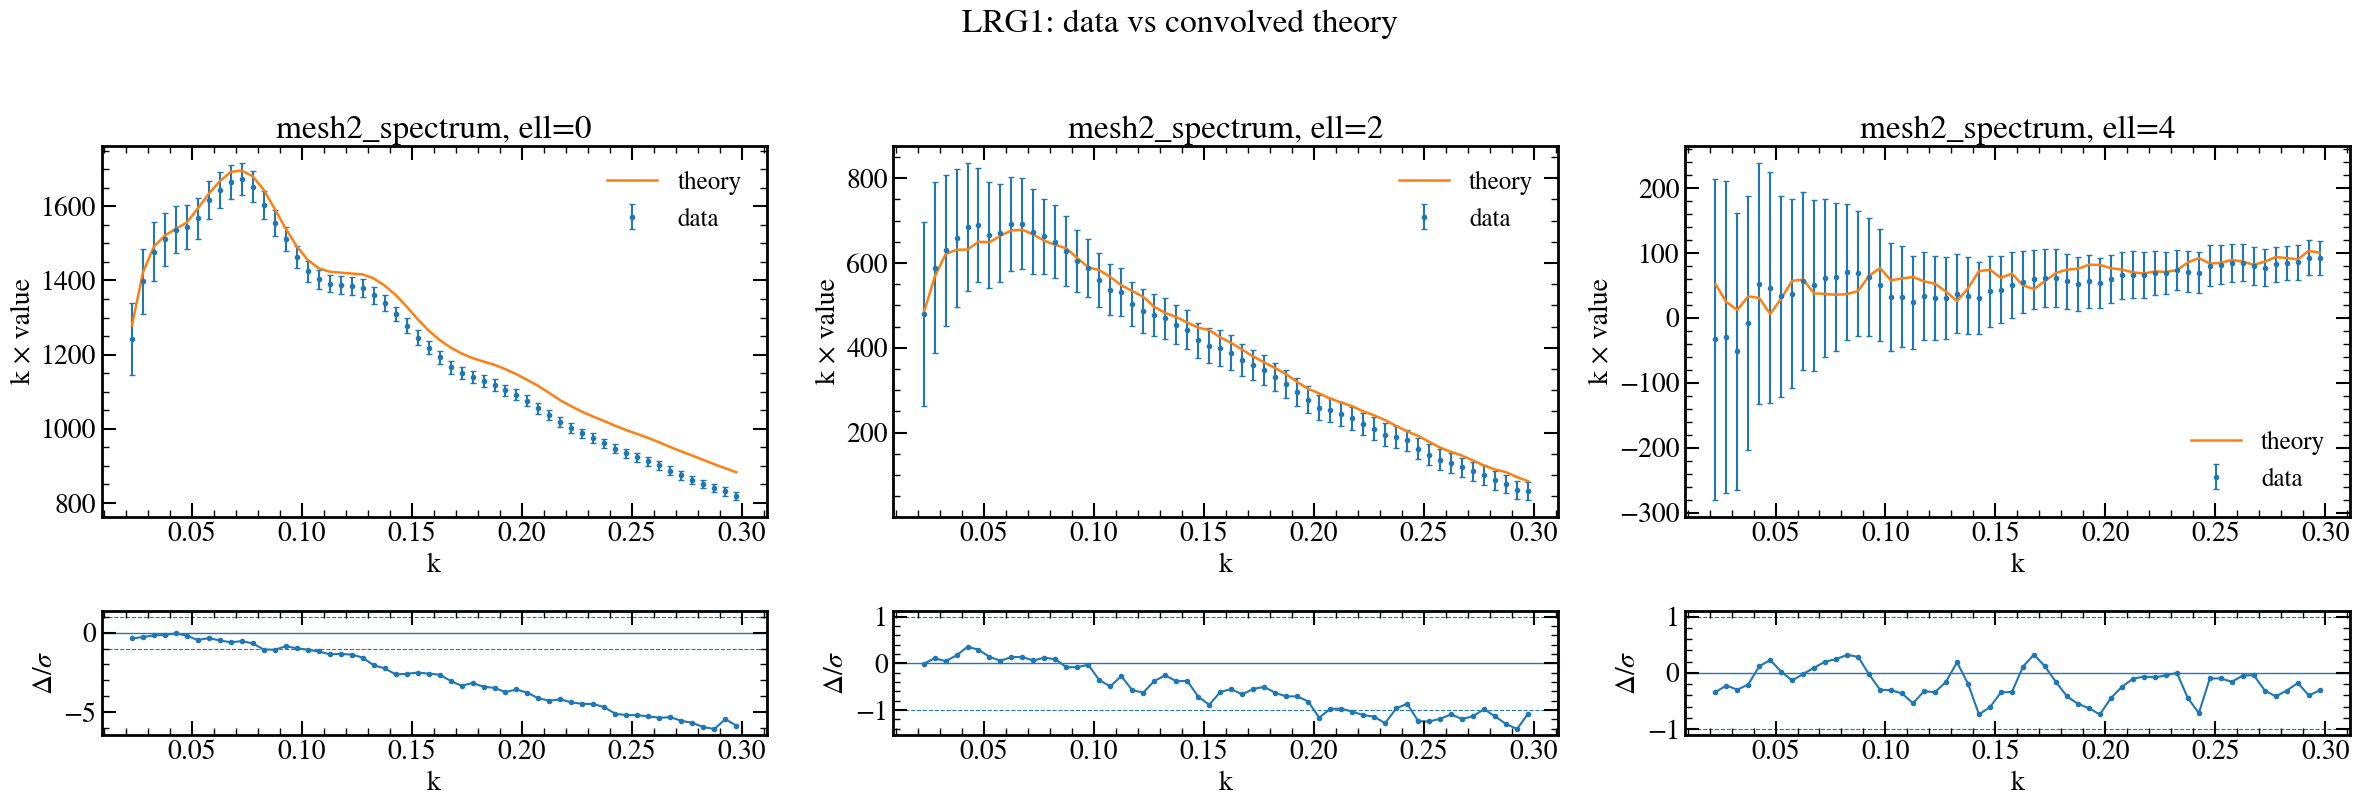

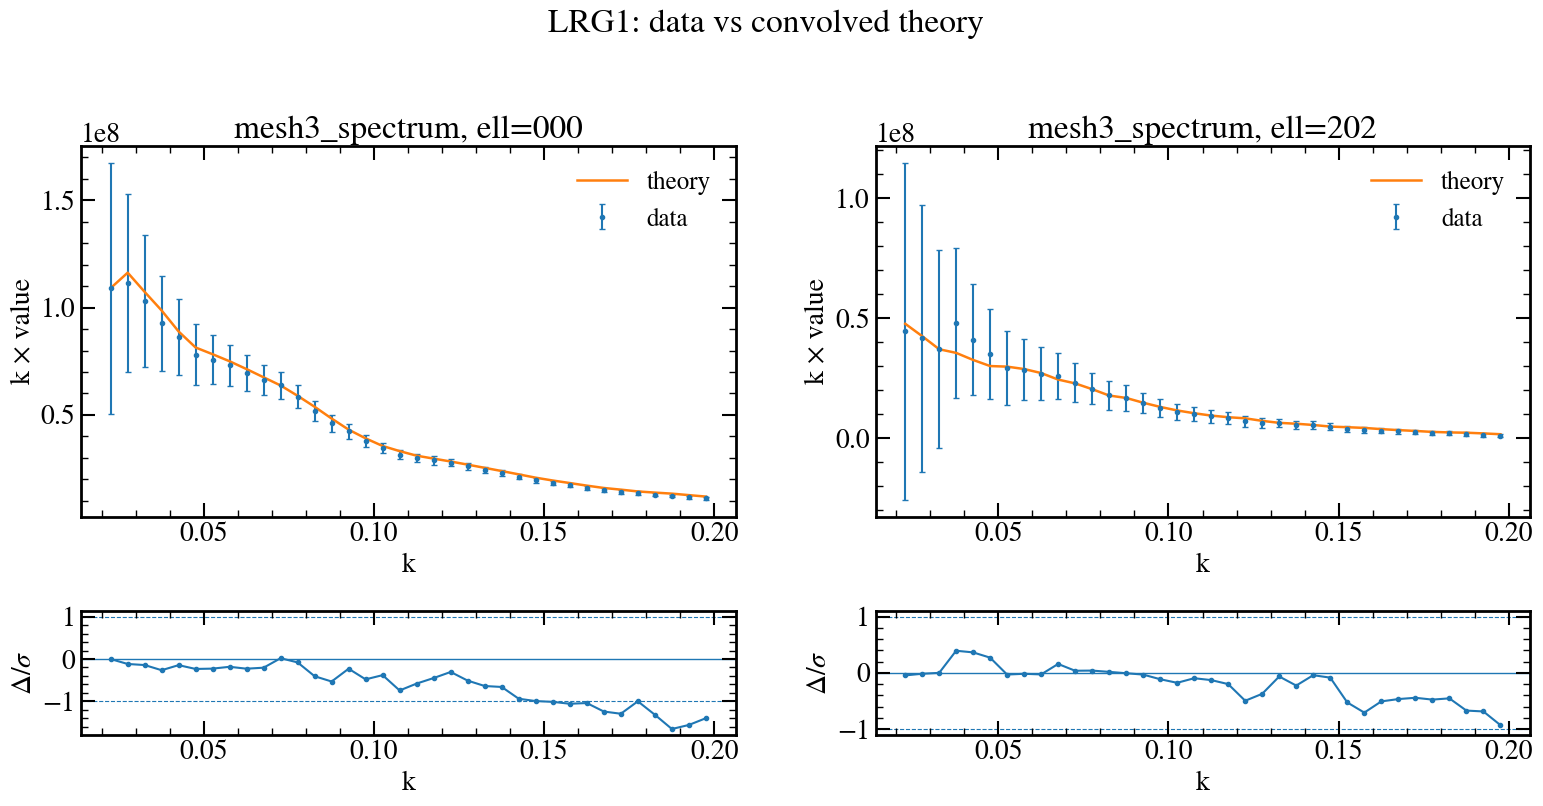

In [10]:
plot_stat_multipoles(engine, model, tracer='LRG1', stat_name='mesh2_spectrum', figsize=(8, 8))
plot_stat_multipoles(engine, model, tracer='LRG1', stat_name='mesh3_spectrum', figsize=(8, 8))

# Uncomment these if you want the same plots for additional tracers
# plot_stat_multipoles(engine, model, tracer='LRG2', stat_name='mesh2_spectrum', figsize=(8, 4.8))
# plot_stat_multipoles(engine, model, tracer='LRG2', stat_name='mesh3_spectrum', figsize=(8, 4.8))

plt.show()

## 9. Inspect the resolved files

This is useful to confirm which HF mocks were used as data, which holimocks entered the covariance, and which window files were loaded.


In [11]:
engine.print_file_info('LRG1')
# engine.print_file_info('LRG2')

Tracer: LRG1
  Stat: mesh2_spectrum
    Data files: 25
      /global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock0/mesh2_spectrum_poles_LRG_z0.4-0.6_GCcomb_weight-default-FKP.h5
      /global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock1/mesh2_spectrum_poles_LRG_z0.4-0.6_GCcomb_weight-default-FKP.h5
      /global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock2/mesh2_spectrum_poles_LRG_z0.4-0.6_GCcomb_weight-default-FKP.h5
      /global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock3/mesh2_spectrum_poles_LRG_z0.4-0.6_GCcomb_weight-default-FKP.h5
      /global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock4/mesh2_spectrum_poles_LRG_z0.4-0.6

## 10. Export data / window / covariance arrays

These helpers are convenient if you want to:
- work outside the engine
- save NumPy arrays for writing your own likelihood functions


In [12]:
data_arrays = extract_data_arrays(engine, 'LRG1')
window_arrays = extract_window_arrays(engine, 'LRG1')
cov_arrays = extract_covariance_arrays(engine, 'LRG1')

# Data examples
k_p0 = data_arrays['mesh2_spectrum'][0]['k']
p0_data = data_arrays['mesh2_spectrum'][0]['value']

k_b000 = data_arrays['mesh3_spectrum'][(0, 0, 0)]['k']
b000_data = data_arrays['mesh3_spectrum'][(0, 0, 0)]['value']

# Window examples
W_pow = window_arrays['mesh2_spectrum']['matrix']
k_obs_p0 = window_arrays['mesh2_spectrum']['observable'][0]['k']
k_th_p0 = window_arrays['mesh2_spectrum']['theory'][0]['k']

W_bis = window_arrays['mesh3_spectrum']['matrix']
k_obs_b000 = window_arrays['mesh3_spectrum']['observable'][(0, 0, 0)]['k']
k_th_b000 = window_arrays['mesh3_spectrum']['theory'][(0, 0, 0)]['k']

# Covariance examples
C_full = cov_arrays['full_matrix']

C_pow = cov_arrays['per_stat']['mesh2_spectrum']['matrix']
k_cov_p0 = cov_arrays['per_stat']['mesh2_spectrum']['k'][0]
std_p0 = cov_arrays['per_stat']['mesh2_spectrum']['std'][0]

C_bis = cov_arrays['per_stat']['mesh3_spectrum']['matrix']
k_cov_b000 = cov_arrays['per_stat']['mesh3_spectrum']['k'][(0, 0, 0)]
std_b000 = cov_arrays['per_stat']['mesh3_spectrum']['std'][(0, 0, 0)]

# Covariance sub-block examples
C_P0P2 = cov_arrays['per_stat']['mesh2_spectrum']['subblocks'][0][2]
C_B000B202 = cov_arrays['per_stat']['mesh3_spectrum']['subblocks'][(0, 0, 0)][(2, 0, 2)]

print("Shapes:")
print("  C_full      =", C_full.shape)
print("  C_P0P2      =", C_P0P2.shape)
print("  C_B000B202  =", C_B000B202.shape)

Shapes:
  C_full      = (240, 240)
  C_P0P2      = (56, 56)
  C_B000B202  = (36, 36)


## 11. Recover the concatenated data-vector ordering

This is the ordering used when flattening the selected observables into the data vector compared against the full covariance matrix.


In [13]:
data_vec, layout = extract_concatenated_layout(engine, 'LRG1')

print("Concatenated data-vector length:", len(data_vec))
print("Layout entries:")
for item in layout:
    print(item['stat'], item['ell'], item['size'])

Concatenated data-vector length: 240
Layout entries:
mesh2_spectrum 0 56
mesh2_spectrum 2 56
mesh2_spectrum 4 56
mesh3_spectrum (0, 0, 0) 36
mesh3_spectrum (2, 0, 2) 36
